# Symptoms → Disease → Doctor — NLP Pipeline

Projekt: system przyjmujący opis objawów w języku naturalnym i przewidujący chorobę oraz specjalizację lekarza.

**Typ problemu:** klasyfikacja tekstu (multi-class).  
**Input:** opis objawów. **Output:** choroba + sugerowany lekarz.

## 1. Problem Definition

Celem jest stworzenie systemu, który:
- przyjmuje opis objawów pacjenta w języku naturalnym,
- przewiduje najbardziej prawdopodobną chorobę,
- sugeruje odpowiednią specjalizację lekarza.

## 2. Data Acquisition

In [1]:
!pip install -q kaggle

# Umieść kaggle.json w ~/.kaggle/ (Linux/Mac) lub odpowiednim katalogu (Windows)
# Następnie pobierz dataset:
!kaggle datasets download -d abhishekgodara/symptoms-to-diseases

import zipfile
with zipfile.ZipFile("symptoms-to-diseases.zip", 'r') as zip_ref:
    zip_ref.extractall("symptoms_dataset")

Dataset URL: https://www.kaggle.com/datasets/abhishekgodara/symptoms-to-diseases
License(s): DbCL-1.0
symptoms-to-diseases.zip: Skipping, found more recently modified local copy (use --force to force download)


## 3. Data Loading

In [2]:
import pandas as pd
import os

data_dir = "symptoms_dataset"
files = os.listdir(data_dir)
print("Pliki w dataset:", files)

# Wczytaj pierwszy plik CSV
csv_files = [f for f in files if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError("Brak pliku CSV w symptoms_dataset")

path = os.path.join(data_dir, csv_files[0])
df = pd.read_csv(path)
print("\nKształt:", df.shape)
print("Kolumny:", df.columns.tolist())
df.head(10)

Pliki w dataset: ['final_symptoms_to_disease.csv', 'data.csv']

Kształt: (192715, 2)
Kolumny: ['diseases', 'symptom_text']


,diseases,symptom_text
0,panic disorder,"anxiety and nervousness, shortness of breath, ..."
1,panic disorder,"shortness of breath, depressive or psychotic s..."
2,panic disorder,"anxiety and nervousness, depression, shortness..."
3,panic disorder,"anxiety and nervousness, depressive or psychot..."
4,panic disorder,"anxiety and nervousness, depression, insomnia,..."
5,panic disorder,"shortness of breath, depressive or psychotic s..."
6,panic disorder,anxiety and nervousness
7,panic disorder,"depressive or psychotic symptoms, insomnia, ab..."
8,panic disorder,"anxiety and nervousness, depressive or psychot..."
9,panic disorder,"anxiety and nervousness, depression, shortness..."


In [3]:
# Dopasowanie nazw kolumn (różne wersje datasetu)
disease_col = None
symptom_col = None
for c in df.columns:
    c_lower = c.lower()
    if 'disease' in c_lower or 'label' in c_lower or c_lower == 'prognosis':
        disease_col = c
    if 'symptom' in c_lower or 'text' in c_lower or 'description' in c_lower:
        symptom_col = c

if disease_col is None:
    disease_col = df.columns[0]  # pierwsza kolumna jako choroba
if symptom_col is None:
    symptom_col = df.columns[1] if len(df.columns) > 1 else df.columns[0]

print("Kolumna choroby:", disease_col)
print("Kolumna objawów:", symptom_col)

df = df[[disease_col, symptom_col]].copy()
df.columns = ['disease', 'symptoms']
df = df.dropna()
df.head()

Kolumna choroby: diseases
Kolumna objawów: symptom_text


,disease,symptoms
0,panic disorder,"anxiety and nervousness, shortness of breath, ..."
1,panic disorder,"shortness of breath, depressive or psychotic s..."
2,panic disorder,"anxiety and nervousness, depression, shortness..."
3,panic disorder,"anxiety and nervousness, depressive or psychot..."
4,panic disorder,"anxiety and nervousness, depression, insomnia,..."


## 4. Exploratory Data Analysis (EDA)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Liczba unikalnych chorób:", df['disease'].nunique())
print("Liczba rekordów:", len(df))
print("\nRozkład klas (top 15):")
df['disease'].value_counts().head(15)

Liczba unikalnych chorób: 254
Liczba rekordów: 192715

Rozkład klas (top 15):


disease
cystitis                          1219
nose disorder                     1218
vulvodynia                        1218
complex regional pain syndrome    1217
spondylosis                       1216
esophagitis                       1215
hypoglycemia                      1215
conjunctivitis due to allergy     1215
peripheral nerve disorder         1215
vaginal cyst                      1215
diverticulitis                    1214
gastrointestinal hemorrhage       1214
acute bronchitis                  1213
pneumonia                         1212
infectious gastroenteritis        1212
Name: count, dtype: int64

Średnia liczba objawów na rekord: 5.61


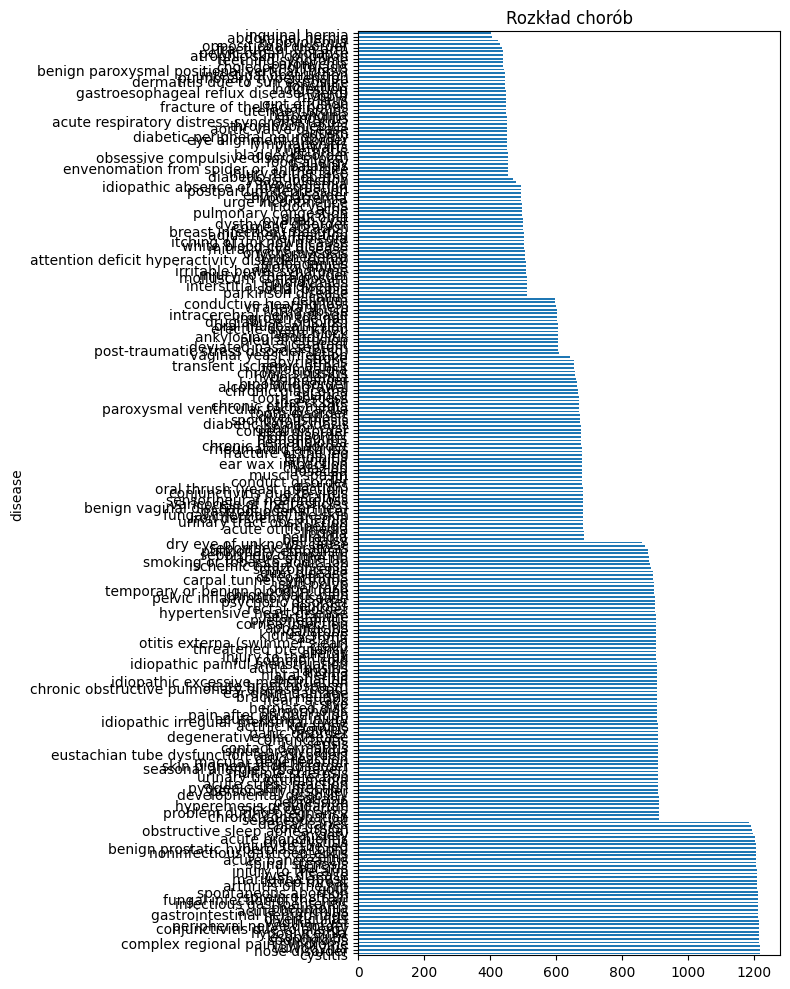

In [5]:
# Liczba objawów na chorobę (np. liczba tokenów po przecinku)
df['symptom_count'] = df['symptoms'].astype(str).str.count(',') + 1
print("Średnia liczba objawów na rekord:", df['symptom_count'].mean().round(2))

df['disease'].value_counts().plot(kind='barh', figsize=(8, 10), title='Rozkład chorób')
plt.tight_layout()
plt.show()

## 5. Data Cleaning

In [6]:
import re

def clean_symptoms(text):
    if pd.isna(text):
        return ""
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z0-9\s,]', ' ', text)  # usuń znaki specjalne
    text = re.sub(r'\s+', ' ', text)  # nadmiarowe spacje
    text = re.sub(r',\s*', ', ', text)  # spójne przecinki
    return text.strip()

df['symptoms_clean'] = df['symptoms'].apply(clean_symptoms)
df[['symptoms', 'symptoms_clean']].head(10)

,symptoms,symptoms_clean
0,"anxiety and nervousness, shortness of breath, ...","anxiety and nervousness, shortness of breath, ..."
1,"shortness of breath, depressive or psychotic s...","shortness of breath, depressive or psychotic s..."
2,"anxiety and nervousness, depression, shortness...","anxiety and nervousness, depression, shortness..."
3,"anxiety and nervousness, depressive or psychot...","anxiety and nervousness, depressive or psychot..."
4,"anxiety and nervousness, depression, insomnia,...","anxiety and nervousness, depression, insomnia,..."
5,"shortness of breath, depressive or psychotic s...","shortness of breath, depressive or psychotic s..."
6,anxiety and nervousness,anxiety and nervousness
7,"depressive or psychotic symptoms, insomnia, ab...","depressive or psychotic symptoms, insomnia, ab..."
8,"anxiety and nervousness, depressive or psychot...","anxiety and nervousness, depressive or psychot..."
9,"anxiety and nervousness, depression, shortness...","anxiety and nervousness, depression, shortness..."


## 6. Tokenization

In [7]:
# Objawy jako lista fraz (tokenów) oddzielonych przecinkami
def tokenize_symptoms(text):
    return [t.strip() for t in str(text).split(',') if t.strip()]

df['symptoms_tokens'] = df['symptoms_clean'].apply(tokenize_symptoms)
df['symptoms_text'] = df['symptoms_clean']  # do vectorizacji używamy tekstu
df[['symptoms_clean', 'symptoms_tokens']].head()

,symptoms_clean,symptoms_tokens
0,"anxiety and nervousness, shortness of breath, ...","[anxiety and nervousness, shortness of breath,..."
1,"shortness of breath, depressive or psychotic s...","[shortness of breath, depressive or psychotic ..."
2,"anxiety and nervousness, depression, shortness...","[anxiety and nervousness, depression, shortnes..."
3,"anxiety and nervousness, depressive or psychot...","[anxiety and nervousness, depressive or psycho..."
4,"anxiety and nervousness, depression, insomnia,...","[anxiety and nervousness, depression, insomnia..."


## 7. Feature Engineering & 8. Target Variable

In [8]:
# NIE używaj lambda — joblib nie zapisze vectorizera. Tylko nazwana funkcja (comma_tokenizer).
from sklearn.feature_extraction.text import CountVectorizer

def comma_tokenizer(text):
    """Tokenizacja po przecinku — funkcja nazwana (wymagana do pickle/joblib)."""
    return [t.strip() for t in str(text).split(',') if t.strip()]

X_text = df['symptoms_text']
y = df['disease']

# Bag of Words — tokenizer=comma_tokenizer (NIE lambda!)
vectorizer = CountVectorizer(tokenizer=comma_tokenizer, lowercase=True, min_df=1)
X = vectorizer.fit_transform(X_text)
print("Wymiar macierzy cech:", X.shape)
print("Liczba cech (unikalnych objawów):", len(vectorizer.get_feature_names_out()))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Wymiar macierzy cech: (192715, 283)
Liczba cech (unikalnych objawów): 283


## 9. Train-Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Trening:", X_train.shape[0], "Test:", X_test.shape[0])

Trening: 154172 Test: 38543


## 10. Model Training

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Naive Bayes': MultinomialNB()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Wytrenowano: {name}")

# Nie ustawiaj tu `model = models['Random Forest']`.
# Model do pipeline'u i zapisu wybieramy dopiero w sekcji **Model Evaluation** (najlepszy model).
# Dzięki temu nie zapisujemy przypadkowo ogromnego Random Foresta do Streamlita.


Wytrenowano: Random Forest
Wytrenowano: Logistic Regression
Wytrenowano: Naive Bayes


## 11. Model Evaluation

=== Porównanie modeli ===
              Model  Accuracy  Precision (weighted)  Recall (weighted)  F1 (weighted)
      Random Forest    0.8371                0.8382             0.8371         0.8373
Logistic Regression    0.8706                0.8769             0.8706         0.8708
        Naive Bayes    0.8648                0.8738             0.8648         0.8657


Classification Report: Random Forest
                                                 precision    recall  f1-score   support

                               abdominal hernia       0.96      0.96      0.96        81
                                           acne       0.68      0.79      0.73        99
                              actinic keratosis       0.74      0.70      0.72       182
                            acute bronchiolitis       0.96      0.89      0.92       241
                               acute bronchitis       0.65      0.69      0.67       243
                             acute bronchospasm       0.

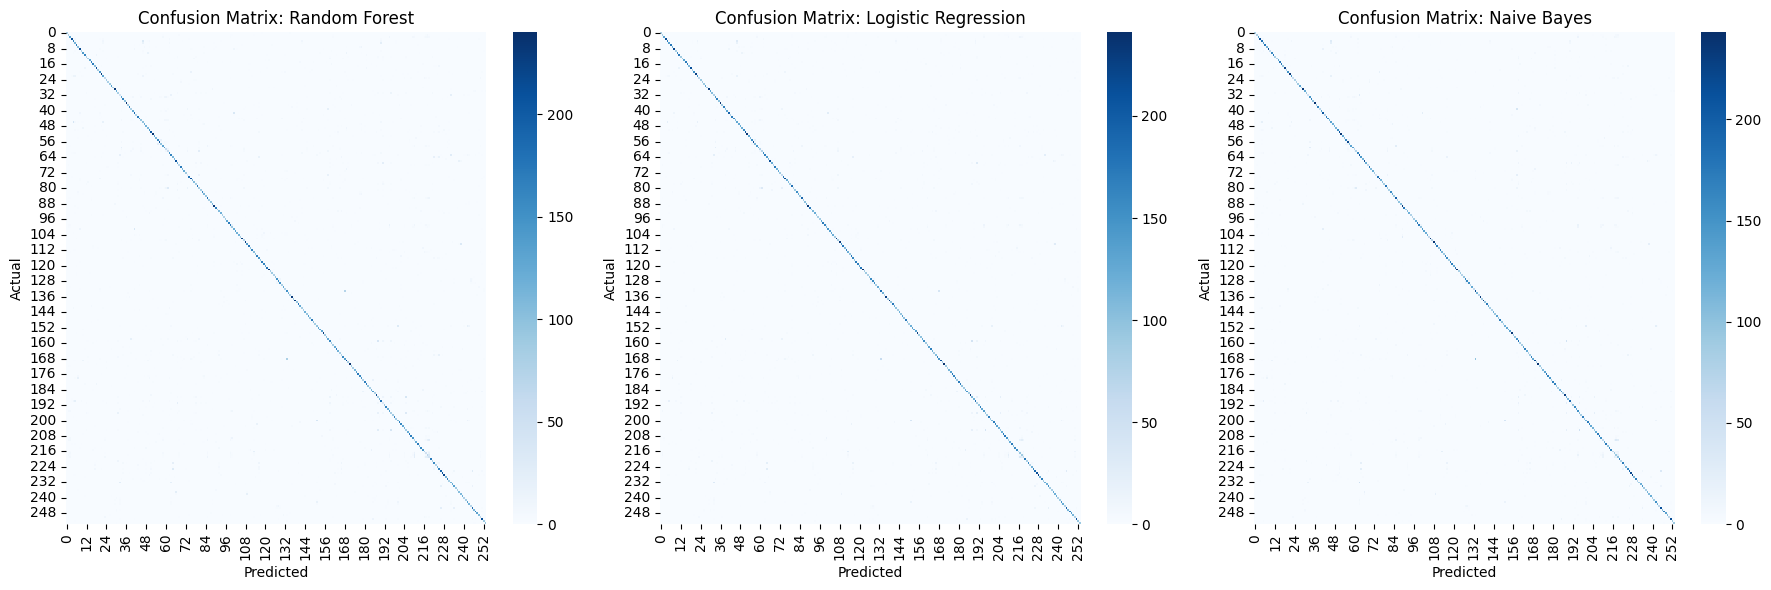

Dla pipeline'u predykcji wybrany model: Logistic Regression


In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Porównanie wszystkich wytrenowanych modeli
results = []
for name, m in models.items():
    y_pred = m.predict(X_test)
    acc = round(accuracy_score(y_test, y_pred), 4)
    prec = round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4)
    rec = round(recall_score(y_test, y_pred, average='weighted', zero_division=0), 4)
    f1 = round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4)
    results.append({'Model': name, 'Accuracy': acc, 'Precision (weighted)': prec, 'Recall (weighted)': rec, 'F1 (weighted)': f1})

df_results = pd.DataFrame(results)
print("=== Porównanie modeli ===")
print(df_results.to_string(index=False))
print()

# Classification report dla każdego modelu
for name, m in models.items():
    y_pred = m.predict(X_test)
    print(f"\n{'='*60}")
    print(f"Classification Report: {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, zero_division=0))

# Macierze pomyłek dla wszystkich modeli (3 subploty)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, m) in zip(axes, models.items()):
    y_pred = m.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Confusion Matrix: {name}")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

# Dalsze kroki używają jednego modelu (np. najlepszy według accuracy)
best_name = df_results.loc[df_results['Accuracy'].idxmax(), 'Model']
model = models[best_name]
print(f"Dla pipeline'u predykcji wybrany model: {best_name}")

## 12. Disease to Doctor Mapping

In [12]:
# Mapowanie chorób na specjalizacje (przykładowe)
DISEASE_TO_DOCTOR = {
    'migraine': 'Neurolog',
    'hypertension': 'Kardiolog',
    'bronchitis': 'Pulmonolog',
    'gastritis': 'Gastroenterolog',
    'arthritis': 'Reumatolog',
    'diabetes': 'Diabetolog / Internista',
    'asthma': 'Pulmonolog',
    'common cold': 'Lekarz rodzinny',
    'flu': 'Lekarz rodzinny',
    'pneumonia': 'Pulmonolog',
    'tuberculosis': 'Pulmonolog',
    'malaria': 'Specjalista chorób zakaźnych',
    'dengue': 'Specjalista chorób zakaźnych',
    'typhoid': 'Specjalista chorób zakaźnych',
    'hepatitis': 'Gastroenterolog / Hepatolog',
    'jaundice': 'Gastroenterolog / Hepatolog',
}

def get_doctor_for_disease(disease):
    d = str(disease).lower().strip()
    for key, doctor in DISEASE_TO_DOCTOR.items():
        if key in d or d in key:
            return doctor
    return 'Lekarz rodzinny (konsultacja ogólna)'

# Uzupełnij mapowanie na podstawie unikalnych chorób w danych
for d in df['disease'].unique():
    d_lower = str(d).lower()
    if d_lower not in [k.lower() for k in DISEASE_TO_DOCTOR]:
        DISEASE_TO_DOCTOR[d_lower] = 'Lekarz rodzinny (konsultacja ogólna)'

print("Przykłady mapowania:", list(DISEASE_TO_DOCTOR.items())[:5])

Przykłady mapowania: [('migraine', 'Neurolog'), ('hypertension', 'Kardiolog'), ('bronchitis', 'Pulmonolog'), ('gastritis', 'Gastroenterolog'), ('arthritis', 'Reumatolog')]


## 13. Prediction Pipeline

In [13]:
def predict_disease_and_doctor(symptoms_input, vectorizer, model, clean_fn, doctor_fn):
    cleaned = clean_fn(symptoms_input)
    if not cleaned or not cleaned.strip():
        return None, None
    try:
        X_in = vectorizer.transform([cleaned])
        if X_in.shape[0] == 0:
            return None, None
        pred = model.predict(X_in)
        if len(pred) == 0:
            return None, None
        disease = pred[0]
        doctor = doctor_fn(disease)
        return disease, doctor
    except (IndexError, Exception) as e:
        print(f"Błąd predykcji: {e}")
        return None, None

# Test
test_input = "headache, fever, cough"
disease, doctor = predict_disease_and_doctor(test_input, vectorizer, model, clean_symptoms, get_doctor_for_disease)
print(f"Objawy: {test_input}")
if disease is not None and doctor is not None:
    print(f"Przewidywana choroba: {disease}")
    print(f"Sugerowany lekarz: {doctor}")
else:
    print("Nie udało się uzyskać predykcji (sprawdź, czy model i vectorizer są wytrenowane w poprzednich komórkach).")

Objawy: headache, fever, cough
Przewidywana choroba: acute bronchitis
Sugerowany lekarz: Pulmonolog


## 14. Streamlit Interface

In [14]:
streamlit_code = '''# streamlit_app.py
import streamlit as st
import pandas as pd
import re
import joblib
from pathlib import Path

st.set_page_config(page_title="Symptoms → Disease → Doctor", page_icon="🩺")
st.title("🩺 Symptoms → Disease → Doctor")
st.write("Wpisz objawy (np. headache, fever, cough), a system zasugeruje chorobę i specjalistę.")

def clean_symptoms(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\\s,]", " ", text)
    text = re.sub(r"\\s+", " ", text)
    return text.strip()

def comma_tokenizer(text):
    return [t.strip() for t in str(text).split(",") if t.strip()]

model_path = Path("model.joblib")
vec_path = Path("vectorizer.joblib")
MIN_VEC_SIZE = 1000
if model_path.exists() and vec_path.exists() and vec_path.stat().st_size >= MIN_VEC_SIZE:
    model = joblib.load(model_path)
    vectorizer = joblib.load(vec_path)
    mapping_path = Path("disease_to_doctor.joblib")
    DISEASE_TO_DOCTOR = joblib.load(mapping_path) if mapping_path.exists() else {}
    def get_doctor(d):
        d = str(d).lower()
        for k, v in DISEASE_TO_DOCTOR.items():
            if k in d: return v
        return "Lekarz rodzinny"
    symptoms = st.text_area("Opis objawów (oddziel przecinkami)", "headache, fever")
    if st.button("Przewidź"):
        cleaned = clean_symptoms(symptoms)
        X = vectorizer.transform([cleaned])
        disease = model.predict(X)[0]
        doctor = get_doctor(disease)
        st.success(f"Przewidywana choroba: **{disease}**")
        st.info(f"Sugerowany lekarz: **{doctor}**")
else:
    if vec_path.exists() and vec_path.stat().st_size < MIN_VEC_SIZE:
        st.warning("vectorizer.joblib uszkodzony lub pusty. Uruchom notebook od sekcji Feature Engineering i komórkę z joblib.dump.")
    else:
        st.warning("Zapisz model i vectorizer (joblib) w tym samym katalogu. W notebooku: Run od Feature Engineering, potem joblib.dump.")
'''

with open("streamlit_app.py", "w", encoding="utf-8") as f:
    f.write(streamlit_code)
print("Zapisano streamlit_app.py. Uruchom: streamlit run streamlit_app.py")

Zapisano streamlit_app.py. Uruchom: streamlit run streamlit_app.py


**Uruchomienie Streamlit w terminalu** (wykonaj 2 linie w katalogu projektu):

In [15]:
import os
# Przejdź do katalogu Symptoms_to_Disease (gdzie jest streamlit_app.py), jeśli jesteś w głównym projekcie
if os.path.exists('Symptoms_to_Disease'):
    os.chdir('Symptoms_to_Disease')

# Uruchom Streamlit tym samym Pythonem co kernel (unikniesz konfliktu wersji scikit-learn)
import sys
!{sys.executable} -m streamlit run streamlit_app.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://192.168.1.165:8502

  Stopping...


In [16]:
# Zapis modelu i vectorizera do użycia w Streamlit (vectorizer z sekcji Feature Engineering, z comma_tokenizer)
import joblib

# Uwaga: bez kompresji Random Forest potrafi zapisać się jako wielogigabajtowy plik i zawiesić Streamlit.
# Dlatego zapisujemy z kompresją.
joblib.dump(model, "model.joblib", compress=3)
joblib.dump(vectorizer, "vectorizer.joblib", compress=3)
joblib.dump(DISEASE_TO_DOCTOR, "disease_to_doctor.joblib", compress=3)
print("Zapisano: model.joblib, vectorizer.joblib, disease_to_doctor.joblib")

Zapisano: model.joblib, vectorizer.joblib, disease_to_doctor.joblib


## 15. Deployment

Gotową aplikację można wdrożyć na:
- **Streamlit Cloud** (streamlit.io)
- **Hugging Face Spaces**
- **Render**

Wymagane: `requirements.txt` z `streamlit`, `pandas`, `scikit-learn`, `joblib`.

## 16. Possible Improvements

- **Embeddings / modele transformerowe:** BERT, BioBERT dla lepszej reprezentacji objawów.
- **Synonimy objawów:** normalizacja do słownika medycznego.
- **Ranking chorób:** zwracanie top-k najbardziej prawdopodobnych chorób.
- **Triage:** ocena pilności konsultacji (np. czerwona/żółta/zielona).